# QAOA Workflow: Problem Creation, Training, and Evaluation

이 노트북은 `test_qaoa` 디렉토리 내의 모듈들을 활용하여 MaxCut 문제를 정의하고, QAOA 회로를 구성하여 학습 및 평가하는 전체 과정을 다룹니다.

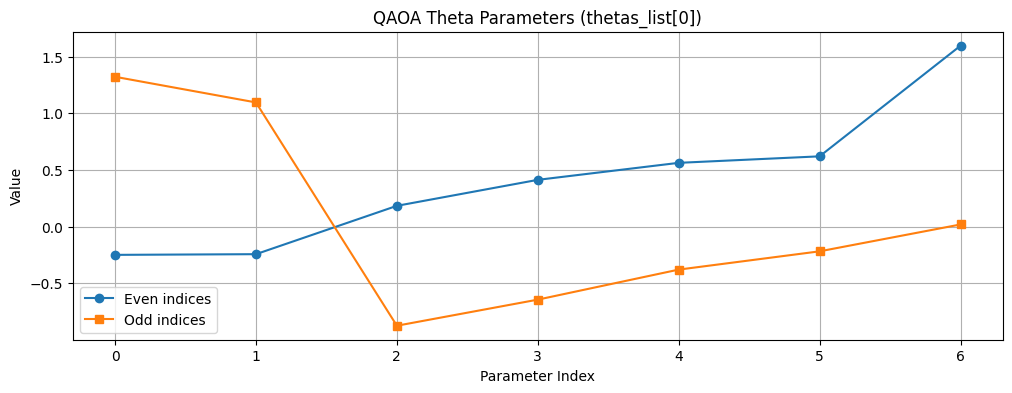

In [1]:
from matplotlib import pyplot as plt
import json
with open('/home/ubuntu/PPS-lab/test_qaoa/results/Q45_L7/training_log.json', 'r' ) as f:
    training_log = json.load(f)

thetas_list = [training_log['initial_thetas']]
thetas_list = [training_log['trained_thetas']]

for idx, theta in enumerate(thetas_list):
    plt.figure(figsize=(12, 4))
    even_indices = [2*i for i in range(len(theta)//2)]
    plt.plot([theta[i] for i in even_indices], marker='o', label='Even indices')
    plt.plot([theta[i] for i in range(1, len(theta), 2)], marker='s', label='Odd indices')
    plt.xlabel('Parameter Index')
    plt.ylabel('Value')
    plt.title(f'QAOA Theta Parameters (thetas_list[{idx}])')
    plt.grid(True)
    plt.legend()
    plt.show()

In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

# 현재 디렉토리와 상위 디렉토리(Repo Root)를 경로에 추가하여 모듈 임포트
current_dir = Path.cwd()
repo_root = current_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# 기존 모듈 임포트
from src_tensor.api import compile_expval_program
from make_graph import _make_erdos_renyi_graph as make_erdos_renyi_graph
from qaoa_surrogate_common import (
    make_ring_chord_graph,
    build_qaoa_circuit,
    build_maxcut_observable,
    build_qaoa_theta_init_tqa,
    expected_cut_from_sum_zz,
    canonical_edge
)

## 1. Configuration & Problem Definition

실험에 사용할 하이퍼파라미터와 그래프 구조를 정의합니다.

In [2]:
# Configuration
N_QUBITS = 30
P_LAYERS = 7
DELTA_T = 0.8  # TQA initialization parameter
STEPS = 150
LR = 0.05
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Set seeds for reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Device: {DEVICE}")
print(f"Problem: N={N_QUBITS}, p={P_LAYERS}")

Device: cuda
Problem: N=30, p=7


Generated graph with 116 edges.


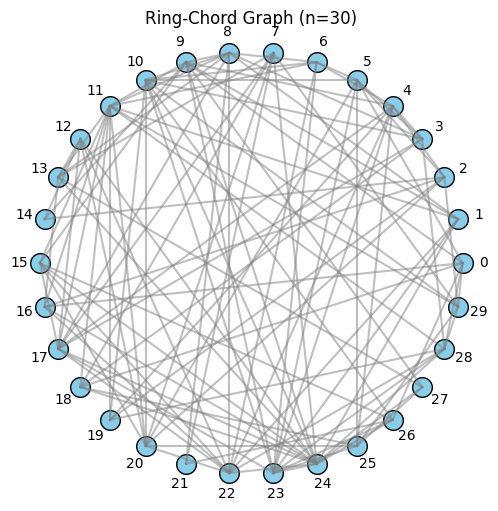

In [3]:
# Create Graph (Ring with Chords)
# edges = make_ring_chord_graph(N_QUBITS, chord_shift=5)


edges = make_erdos_renyi_graph(n_qubits = N_QUBITS, edge_prob=0.25, seed=SEED,
                               ensure_connected=True, max_tries=3)
m_edges = len(edges)

print(f"Generated graph with {m_edges} edges.")

# Simple Visualization
def plot_graph_circle(n, edges):
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    x = np.cos(theta)
    y = np.sin(theta)
    
    plt.figure(figsize=(6, 6))
    # Draw edges
    for u, v in edges:
        plt.plot([x[u], x[v]], [y[u], y[v]], color="gray", alpha=0.5)
    # Draw nodes
    plt.scatter(x, y, s=200, c='skyblue', edgecolors='black')
    for i in range(n):
        plt.text(x[i]*1.1, y[i]*1.1, str(i), ha='center', va='center')
    plt.axis('off')
    plt.title(f"Ring-Chord Graph (n={n})")
    plt.show()

plot_graph_circle(N_QUBITS, edges)

## 2. Build QAOA Circuit & Model

QAOA 회로를 구성하고, Random 또는 TQA(Trotterized Quantum Annealing) 방식으로 파라미터를 초기화합니다.
그 후 `compile_expval_program`을 통해 미분 가능한 Surrogate 프로그램을 생성합니다.

In [4]:
# 1. Build Circuit Structure
circuit, n_params = build_qaoa_circuit(N_QUBITS, edges, P_LAYERS)
zz_obj = build_maxcut_observable(N_QUBITS, edges)

# 2. Initialize Parameters (TQA)
# init_theta_np = build_qaoa_theta_init_tqa(
#     p_layers=P_LAYERS,
#     n_edges=m_edges,
#     n_qubits=N_QUBITS,
#     delta_t=DELTA_T,
#     dtype=np.float64
# )
init_theta_np = np.random.uniform(size= 2 * P_LAYERS)  # Randomize initial thetas
    
# Convert to PyTorch Parameter
thetas = torch.nn.Parameter(
    torch.tensor(init_theta_np, dtype=torch.float64, device=DEVICE)
)

# 3. Compile Surrogate Program
program = compile_expval_program(
    circuit=circuit,
    observables=[zz_obj],
    preset="hybrid",
    preset_overrides={'max_weight':3,                    
    'chunk_size' : 10_000_000}
    )

print("Program compiled successfully.")

propagate: 100%|██████████| 1052/1052 [00:17<00:00, 59.07it/s]


[PPS Info] Propagation complete. Terms generated: 29,497
Starting zero-filtering on cuda...
[ZeroFilter] Initial pruning (diagonal terms only): 29,497 -> 465 terms kept (1.57643150%)
[ZeroFilter] Zero-filtering done. Starting back-propagation of keep mask through 1052 steps...


zero-filter: 100%|██████████| 1052/1052 [00:03<00:00, 332.50it/s, step=0 rows=123 cols=116 nnz=7]        

Program compiled successfully.


## 3. Training Loop

PyTorch의 Adam Optimizer를 사용하여 QAOA 파라미터를 최적화합니다.
목표 함수는 Hamiltonian의 기댓값(Energy)이며, 이를 최소화합니다 (MaxCut은 에너지를 최소화하면 컷이 최대화됨).

In [6]:
optimizer = torch.optim.Adam([thetas], lr=LR)
history_loss = []
history_cut = []

print(f"Starting training for {STEPS} steps...")

save_checkpoints = [1, 10, 50, 150]
thetas_dict = {f"theta_{i}": None for i in save_checkpoints}
for step in range(STEPS):
    optimizer.zero_grad()
    
    # Calculate Expectation Value <H>
    loss = program.expval(thetas, obs_index=0)
    
    loss.backward()
    optimizer.step()
    
    # Logging
    val = loss.item()
    exp_cut = expected_cut_from_sum_zz(val, m_edges)
    
    history_loss.append(val)
    history_cut.append(exp_cut)
    
    if step % 25 == 0 or step == STEPS - 1:
        print(f"Step {step:03d} | Loss(Sum<ZZ>): {val:+.4f} | Expected Cut: {exp_cut:.4f}")

    if step + 1 in save_checkpoints:
        thetas_dict[f"theta_{step+1}"] = thetas.detach().cpu().numpy()

print("Training complete.")

Starting training for 150 steps...
Step 000 | Loss(Sum<ZZ>): +1.1080 | Expected Cut: 57.4460
Step 025 | Loss(Sum<ZZ>): -32.3119 | Expected Cut: 74.1559
Step 050 | Loss(Sum<ZZ>): -34.9694 | Expected Cut: 75.4847
Step 075 | Loss(Sum<ZZ>): -36.0948 | Expected Cut: 76.0474
Step 100 | Loss(Sum<ZZ>): -36.8889 | Expected Cut: 76.4444
Step 125 | Loss(Sum<ZZ>): -36.9503 | Expected Cut: 76.4752
Step 149 | Loss(Sum<ZZ>): -36.9564 | Expected Cut: 76.4782
Training complete.


## 4. Evaluation & Visualization

학습 과정에서의 Expected Cut 변화를 시각화하고, 초기 상태와 학습 후 상태를 비교합니다.

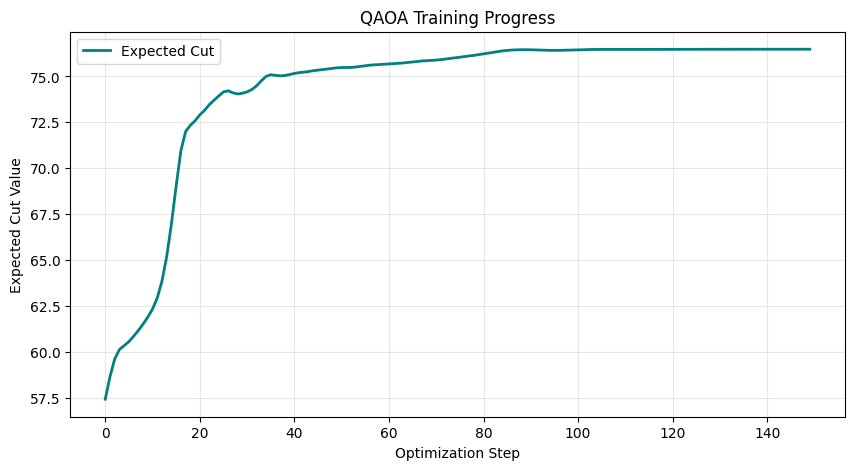

In [7]:
# Plot Training Curve
plt.figure(figsize=(10, 5))
plt.plot(history_cut, label="Expected Cut", color="teal", linewidth=2)
plt.xlabel("Optimization Step")
plt.ylabel("Expected Cut Value")
plt.title("QAOA Training Progress")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Initial Expected Cut: 57.4460
Final Expected Cut:   76.4782
Improvement:          +19.0322


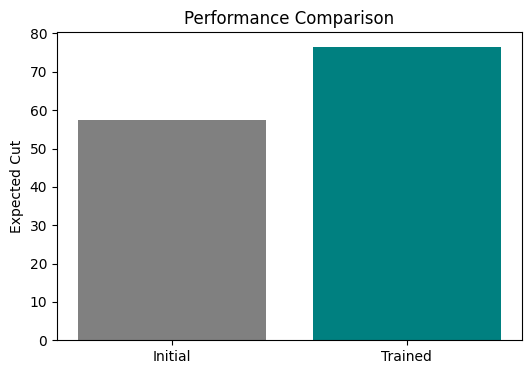

In [8]:
# coeff 

# Compare Initial vs Final
initial_cut = history_cut[0]
final_cut = history_cut[-1]

print(f"Initial Expected Cut: {initial_cut:.4f}")
print(f"Final Expected Cut:   {final_cut:.4f}")
print(f"Improvement:          {final_cut - initial_cut:+.4f}")

# Bar Chart
plt.figure(figsize=(6, 4))
plt.bar(["Initial", "Trained"], [initial_cut, final_cut], color=["gray", "teal"])
plt.ylabel("Expected Cut")
plt.title("Performance Comparison")
plt.show()

## CUDA-Q 샘플링

In [9]:
import cudaq
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Any, Optional

# -----------------------------------------------------------------------------
# 1. Helper Functions (스크립트에서 추출)
# -----------------------------------------------------------------------------

def _bits_from_code(code: int, n_qubits: int) -> np.ndarray:
    """정수 코드를 비트 배열로 변환"""
    bits = np.zeros((int(n_qubits),), dtype=np.uint8)
    for q in range(int(n_qubits)):
        bits[q] = (int(code) >> q) & 1
    return bits

def _parse_counts_keys(counts: Dict[str, int], n_qubits: int, bit_order: str) -> Dict[int, int]:
    """CUDA-Q 결과(비트스트링 키)를 정수 키로 변환"""
    out: Dict[int, int] = {}
    for k, v in counts.items():
        ks = str(k).strip()
        if all(ch in ("0", "1") for ch in ks) and len(ks) == int(n_qubits):
            code = 0
            if str(bit_order) == "le":
                for i, ch in enumerate(ks):
                    code |= (int(ch) & 1) << i
            else:
                for i, ch in enumerate(ks):
                    code |= (int(ch) & 1) << (int(n_qubits) - 1 - i)
        elif ks.isdigit():
            code = int(ks)
        else:
            raise ValueError(f"invalid bitstring key: {k}")
        out[int(code)] = int(v)
    return out

def cut_value_from_bits(bits01, edges) -> int:
    """비트열에 대한 MaxCut 값 계산"""
    val = 0
    for u, v in edges:
        val += int(int(bits01[int(u)]) != int(bits01[int(v)]))
    return int(val)

def _try_cudaq_sample(
    *,
    n_qubits: int,
    edges,
    p_layers: int,
    thetas: np.ndarray,
    shots: int,
    seed: Optional[int],
) -> Dict[str, Any]:
    """CUDA-Q 커널 생성 및 샘플링 수행"""
    
    # 파라미터 준비
    thetas = np.asarray(thetas, dtype=np.float64).reshape(-1)
    params_list = [float(x) for x in thetas.tolist()]
    
    # 커널 정의
    kernel, params = cudaq.make_kernel(list[float])
    q = kernel.qalloc(int(n_qubits))
    
    # 초기 상태 |+>
    for i in range(int(n_qubits)):
        kernel.h(q[i])

    # QAOA 레이어 적용
    for layer in range(int(p_layers)):
        gamma_idx = 2 * layer
        beta_idx = 2 * layer + 1
        for (u, v) in edges:
            uu = int(u)
            vv = int(v)
            # ZZ rotation: CNOT - RZ - CNOT
            kernel.cx(q[uu], q[vv])
            kernel.rz(params[gamma_idx], q[vv])
            kernel.cx(q[uu], q[vv])
        for i in range(int(n_qubits)):
            kernel.rx(params[beta_idx], q[i])

    # 측정
    kernel.mz(q)

    if seed is not None:
        cudaq.set_random_seed(int(seed))

    # 샘플링 실행
    counts = cudaq.sample(kernel, params_list, shots_count=int(shots))
    return {str(k): int(v) for k, v in counts.items()}

# -----------------------------------------------------------------------------
# 2. Main Execution Block
# -----------------------------------------------------------------------------

# (1) 환경 변수 및 데이터 준비
# thetas가 Tensor일 경우 numpy로 변환
if hasattr(thetas, "detach"):
    thetas_np = thetas.detach().cpu().numpy().flatten()
else:
    thetas_np = np.array(thetas).flatten()

# N_QUBITS가 정의되어 있지 않다면 edges에서 유추
if 'N_QUBITS' in locals():
    n_qubits_val = N_QUBITS
else:
    n_qubits_val = max(max(e) for e in edges) + 1

# p_layers 유추 (파라미터 개수 / 2)
p_layers_val = len(thetas_np) // 2
shots_val = 4000
seed_val = 42

print(f"Running CUDA-Q Sampling: N={n_qubits_val}, p={p_layers_val}, shots={shots_val}")

# (2) 샘플링 수행
print("Sampling with initial parameters...")
counts_1st = _try_cudaq_sample(
    n_qubits=n_qubits_val,
    edges=edges,
    p_layers=p_layers_val,
    thetas=thetas_dict["theta_1"],
    shots=shots_val,
    seed=seed_val
)

print("Sampling with trained parameters (10th step)...")    
counts_10th = _try_cudaq_sample(
    n_qubits=n_qubits_val,
    edges=edges,
    p_layers=p_layers_val,
    thetas=thetas_dict["theta_10"],
    shots=shots_val,
    seed=seed_val
)

print("Sampling with trained parameters (50th step)...")
counts_50th = _try_cudaq_sample(
    n_qubits=n_qubits_val,
    edges=edges,
    p_layers=p_layers_val,
    thetas=thetas_dict["theta_50"],
    shots=shots_val,
    seed=seed_val
)

print("Sampling with trained parameters (150th step)...")
counts_150th = _try_cudaq_sample(
    n_qubits=n_qubits_val,
    edges=edges,
    p_layers=p_layers_val,
    thetas=thetas_dict["theta_150"],
    shots=shots_val,
    seed=seed_val
)

Running CUDA-Q Sampling: N=30, p=7, shots=4000
Sampling with initial parameters...
Sampling with trained parameters (10th step)...
Sampling with trained parameters (50th step)...
Sampling with trained parameters (150th step)...


--- Initial Parameters (Random) ---
Mean Cut: 58.25
Max Cut : 78

--- Trained Parameters (10th) ---
Mean Cut: 61.15
Max Cut : 81

--- Trained Parameters (50th) ---
Mean Cut: 78.19
Max Cut : 86

--- Trained Parameters (150th) ---
Mean Cut: 77.33
Max Cut : 86


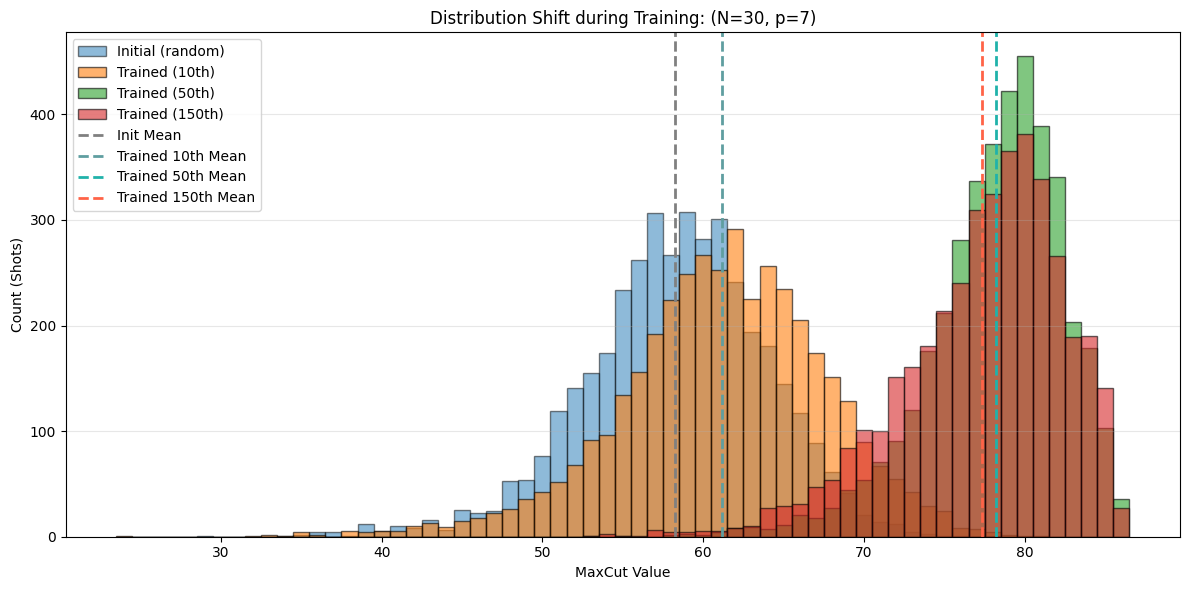

In [11]:
# -----------------------------------------------------------------------------
# 3. Visualization & Analysis
# -----------------------------------------------------------------------------

def get_cut_values(counts_dict, n_qubits, edges):
    """샘플링 결과(counts)를 MaxCut 값들의 배열로 변환"""
    # bit_order는 기본적으로 "le" (Little Endian) 사용
    code_counts = _parse_counts_keys(counts_dict, n_qubits, "le")
    vals = []
    for code, cnt in code_counts.items():
        bits = _bits_from_code(code, n_qubits)
        cut = cut_value_from_bits(bits, edges)
        vals.extend([cut] * cnt)
    return np.array(vals)

# (1) 데이터 변환
cuts_1st = get_cut_values(counts_1st, n_qubits_val, edges)
cuts_10th = get_cut_values(counts_10th, n_qubits_val, edges)
cuts_50th = get_cut_values(counts_50th, n_qubits_val, edges)
cuts_150th = get_cut_values(counts_150th, n_qubits_val, edges)

# (2) 통계 출력
print(f"--- Initial Parameters (Random) ---")
print(f"Mean Cut: {np.mean(cuts_1st):.2f}")
print(f"Max Cut : {np.max(cuts_1st)}")

print(f"\n--- Trained Parameters (10th) ---")
print(f"Mean Cut: {np.mean(cuts_10th):.2f}")
print(f"Max Cut : {np.max(cuts_10th)}")

print(f"\n--- Trained Parameters (50th) ---")
print(f"Mean Cut: {np.mean(cuts_50th):.2f}")
print(f"Max Cut : {np.max(cuts_50th)}") 

print(f"\n--- Trained Parameters (150th) ---")
print(f"Mean Cut: {np.mean(cuts_150th):.2f}")   
print(f"Max Cut : {np.max(cuts_150th)}")

# (3) 히스토그램 시각화
plt.figure(figsize=(12, 6))

# X축 범위 설정 (두 분포를 모두 포함하도록)
all_cuts = np.concatenate([cuts_1st, cuts_10th, cuts_50th, cuts_150th])
min_val = int(np.min(all_cuts))
max_val = int(np.max(all_cuts))
bins = np.arange(min_val, max_val + 2) - 0.5

plt.hist(cuts_1st, bins=bins, alpha=0.5, label='Initial (random)', edgecolor='black', density=False)
plt.hist(cuts_10th, bins=bins, alpha=0.6, label='Trained (10th)',  edgecolor='black', density=False)
plt.hist(cuts_50th, bins=bins, alpha=0.6, label='Trained (50th)',  edgecolor='black', density=False)
plt.hist(cuts_150th, bins=bins, alpha=0.6, label='Trained (150th)', edgecolor='black', density=False)

plt.axvline(np.mean(cuts_1st), color='gray', linestyle='--', linewidth=2, label='Init Mean')
plt.axvline(np.mean(cuts_10th), color='#5f9ea0', linestyle='--', linewidth=2, label='Trained 10th Mean')
plt.axvline(np.mean(cuts_50th), color='#20b2aa', linestyle='--', linewidth=2, label='Trained 50th Mean')
plt.axvline(np.mean(cuts_150th), color='#ff6347', linestyle='--', linewidth=2, label='Trained 150th Mean')

plt.xlabel("MaxCut Value")
plt.ylabel("Count (Shots)")
plt.title(f"Distribution Shift during Training: (N={n_qubits_val}, p={p_layers_val})")
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()